# Importing

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt' , 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

#Building the vocabulary of characters and mapping to/from integers

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


# Spliting data into train , dev and testing part

In [10]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))



# Building the dataset

In [15]:
block_size = 3 # no. of characters to be taken for prediction

def build_dataset(words):
  X,Y = [],[]

  for w in words:

    context = [0]*block_size
    for ch in w + '.' :
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape , Y.shape)
  return X,Y

Xtr , Ytr  = build_dataset(words[:n1])
Xdev , Ydev  = build_dataset(words[n1:n2])
Xte , Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


# Generating parameters

In [21]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10) , generator = g)
W1 = torch.randn((30 , 200) , generator = g)
b1 = torch.randn(200  , generator = g)
W2 = torch.randn((200 , 27) , generator = g)
b2 = torch.randn(27 , generator = g)

parameters = [C , W1 , b1 , W2 , b2]
sum(p.nelement() for p in parameters)

11897

In [23]:
for p in parameters:
  p.requires_grad = True

In [24]:
# lre = torch.linspace(-3 , 0 , 1000)
# lrs = 10**lre

In [26]:
lri = []
lossi = []
stepi = []


In [27]:
for i in range(200000):
  # construction of minibatch
  ix = torch.randint(0 , Xtr.shape[0] , (32, ))

  emb = C[Xtr[ix]]
  h  = torch.tanh(emb.view(-1 ,30 ) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits , Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr*p.grad

  stepi.append(i)
  lossi.append(loss.log10().item())




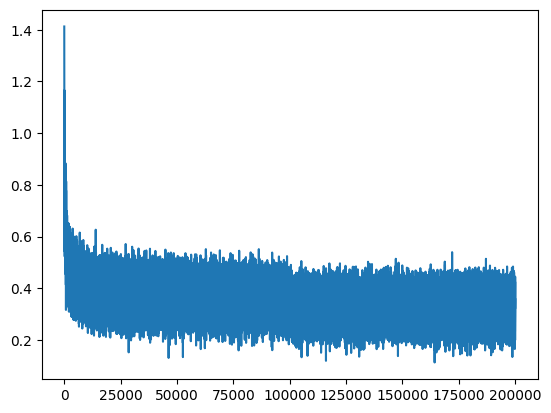

In [38]:
plt.plot(stepi , lossi)

# Training loss

In [29]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1 , 30) @ W1 +b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Ytr)
loss


tensor(2.1483, grad_fn=<NllLossBackward0>)

# Validation loss

In [30]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1 , 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Ydev)
loss

tensor(2.1914, grad_fn=<NllLossBackward0>)

# Testing loss

In [31]:
emb = C[Xte]
h = torch.tanh(emb.view(-1 ,30) @ W1 + b1)
logits = h @ W2 +b2
loss = F.cross_entropy(logits , Yte)
loss

tensor(2.1960, grad_fn=<NllLossBackward0>)

# visualize dimensions 0 and 1 of the embedding matrix C for all characters

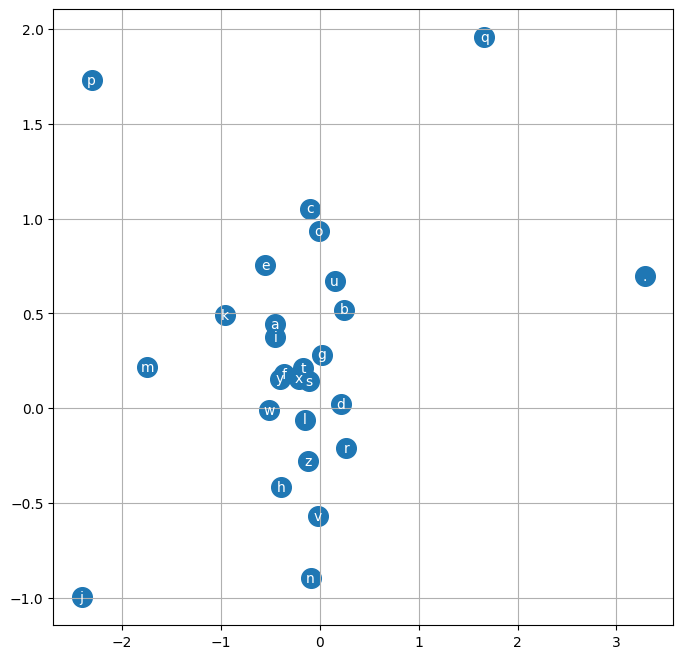

In [32]:
plt.figure(figsize = (8,8))
plt.scatter(C[:,0].data , C[:,1].data , s = 200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i,1].item() , itos[i] , ha = "center" , va = "center"  ,color = "white")
plt.grid('minor')

# Sampling from the model

In [36]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
  out = []
  context = [0]*block_size
  while True:
    emb = C[torch.tensor([context])]
    h = torch.tanh(emb.view(1 , -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs  = F.softmax(logits ,dim = 1)
    ix = torch.multinomial(probs , num_samples = 1 , generator = g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))


carlah.
amillivi.
kimly.
jehton.
kanden.
jazhnen.
delynn.
jareei.
nezmari.
chriiv.
kaleigh.
ham.
joir.
quinn.
salin.
alianni.
wazell.
dearyni.
jaxeeniru.
bred.
